# E61 · Decisions from dynamics: Turing patterns and kinetic proofreading

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | **Part A** (patterns) is **simulated**: the Schnakenberg activator-inhibitor model in dimensionless units on a 128 × 128 periodic grid, imaged while the pattern grows and once it has settled; plus four effective diffusion coefficients of Nodal and Lefty proteins in zebrafish embryos (Müller et al. 2012, TRANSCRIBED as quoted by Kuhn et al. 2022). **Part B** (T cells) is **real**: CD69 dose-response curves of human T cells carrying the 1G4 T-cell receptor, stimulated by 8 variants of the NY-ESO-1 peptide in 5 experiments, with the receptor's measured affinity for each (Pettmann et al. 2021, eLife, CC BY 4.0) |
| **You will learn** | **Turing's instability**: linear stability analysis of a reaction-diffusion system, the conditions for a **diffusion-driven instability**, the band of unstable wavenumbers and the predicted **wavelength** · a **semi-implicit spectral (FFT) solver** for 2-D patterns (spots and stripes) in NumPy · why a **finished pattern identifies little** beyond its wavelength (a feature likelihood by importance sampling, calibrated against simulation) · an **exact likelihood from the linearised dynamics**: early images of a growing pattern are Gaussian in Fourier space, mode by mode, and a Woodbury identity makes that likelihood cheap enough for NUTS · the **posterior probability that the Turing conditions hold** (Nodal/Lefty) and the **size of Turing space** (the fine-tuning problem) · **kinetic proofreading** (Hopfield 1974, Ninio 1975, McKeithan 1995): accuracy beyond the equilibrium limit, paid for in speed and sensitivity · a proofreading model of **T-cell antigen potency** fitted to real dose-response data with the **discrete number of steps $N$ summed out**, a reparameterisation that removes the multimodality this creates, and the **$N$ vs rate trade-off** · **Bayesian experimental design**: which ligand affinities would count the proofreading steps |

## Cells decide with chemistry that is sloppy

A cell's molecules move by diffusion and react by chance, and the energy differences it has to work
with are small. Yet a leopard's skin has regularly spaced spots, digits and hair follicles form at
regular intervals, and a T cell can tell a foreign peptide from a self peptide that binds its receptor
only a few times more weakly. Two ideas from theoretical biology explain how precise outcomes can come
out of imprecise chemistry, and both are about **dynamics** rather than equilibrium.

- **Turing patterns** (Turing 1952): two interacting chemicals that diffuse at different rates can
  turn a uniform tissue into a periodic pattern whose spacing is set by the reaction and diffusion
  rates, not by any template. Diffusion, which normally smooths things out, creates the pattern.
- **Kinetic proofreading** (Hopfield 1974; Ninio 1975): if a decision is only taken after a molecule
  has stayed bound through several energy-consuming steps, the difference in binding times between a
  right and a wrong partner is amplified once per step. T-cell receptors are thought to work this way
  (McKeithan 1995).

Both turn physics into a decision, and both raise the same questions for a Bayesian: what can the data
we can actually collect (an image of a pattern, a dose-response curve) tell us about the mechanism,
how probable is it that the mechanism works at all given uncertain parameters, and which experiment
would tell us more?

## The plan

**Part A · Turing patterns**

1. Activator, inhibitor and Turing's instability
2. Growing a pattern: a semi-implicit spectral solver
3. What a finished pattern can tell you
4. Watching the pattern grow: an exact likelihood from mode growth
5. Is it Turing? Nodal and Lefty, and the size of Turing space

**Part B · Kinetic proofreading**

6. Hopfield's trick: accuracy paid for with time
7. Data: how T cells respond to weaker and weaker antigens
8. A proofreading model of potency, with the number of steps summed out
9. Counting steps: the trade-off between $N$ and the proofreading rate
10. Which ligands would count the steps?

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

from pymc_challenges import data

RANDOM_SEED = 61
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
plt.rcParams["axes.titlesize"] = 11
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="The effect of Potentials")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def report(idata, var_names, label, t_fit=None):
    """Print time, divergences and the worst r_hat / bulk ESS of the named variables."""
    s = az.summary(idata, var_names=var_names, round_to=4)
    div = int(idata.sample_stats["diverging"].sum())
    tt = f"{t_fit:.0f} s, " if t_fit is not None else ""
    print(f"{label}: {tt}{div} divergences, max r_hat {s['r_hat'].max():.3f}, "
          f"min bulk ESS {s['ess_bulk'].min():.0f}, "
          f"warm-up {idata.posterior.attrs.get('tuning_steps', '?')} steps")
    return s

PyMC 6.3.2, ArviZ 1.3.0


# Part A · Turing patterns

## 1 · Activator, inhibitor and Turing's instability

The **Schnakenberg** model is the simplest reaction-diffusion system that makes Turing patterns. An
activator $u$ is produced at a constant rate, promotes its own production by an autocatalytic
step $2u + v \to 3u$, and in doing so uses up a substrate $v$, which is supplied at a constant rate
and diffuses faster. In dimensionless form (lengths in units of $\sqrt{D_u/k}$ for a reference rate
$k$, so that $D_u = 1$),

$$\partial_t u = \gamma\,(a - u + u^2 v) + \nabla^2 u, \qquad
  \partial_t v = \gamma\,(b - u^2 v) + d\,\nabla^2 v .$$

Here $a, b$ are the supply rates, $\gamma$ scales all reaction rates relative to diffusion (and hence
the size of the pattern relative to the dish) and $d = D_v / D_u$ is the ratio of diffusion
coefficients. This is "substrate depletion": a local excess of $u$ grows by eating the $v$ around it,
and because $v$ diffuses fast, it is depleted over a wide area, which stops other peaks from growing
nearby. Fast long-range inhibition plus slow local activation is Turing's recipe; Gierer and Meinhardt
(1972) wrote the same logic with an explicit inhibitor.

**Linear stability.** The uniform steady state is $u^* = a + b$, $v^* = b / (a+b)^2$. Write
$s = a + b$ and $\rho = a / (a + b)$ (the share of the supply that goes directly to the activator).
The Jacobian of the reactions there is

$$J = \begin{pmatrix} f_u & f_v \\ g_u & g_v \end{pmatrix}
    = \begin{pmatrix} 1 - 2\rho & s^2 \\ -2(1-\rho) & -s^2 \end{pmatrix}.$$

A small perturbation $\propto e^{i\mathbf{k}\cdot\mathbf{x}}$ with wavenumber $k = |\mathbf{k}|$
evolves as $e^{A(k) t}$ with $A(k) = \gamma J - k^2\,\mathrm{diag}(1, d)$. Its growth rate
$\lambda(k)$, the larger real part of the eigenvalues of $A(k)$, is the **dispersion relation**.
A **Turing instability** means that the uniform state is stable without diffusion ($k = 0$) but
unstable for some band of $k > 0$:

1. $\operatorname{tr} J = f_u + g_v < 0$, i.e. $1 - 2\rho < s^2$ (stable without diffusion);
2. $\det J = s^2 > 0$ (always true here);
3. $f_u > 0$ (the activator activates itself: $\rho < 1/2$);
4. $d\,f_u + g_v > 2\sqrt{d \det J}$, which is $d > d_c$ with
   $d_c = \left[\big(\sqrt{\det J} + \sqrt{\det J - f_u g_v}\big)/f_u\right]^2
   = s^2 \left[\big(1 + \sqrt{2 - 2\rho}\big) / (1 - 2\rho)\right]^2 .$

The inhibitor (here the substrate) must diffuse at least $d_c$ times faster than the activator. For
$a = 0.1$, $b = 0.9$ ($s = 1$, $\rho = 0.1$) that is $d_c = 8.6$. Above it, $\lambda(k) > 0$ in a band
of wavenumbers, and the **fastest-growing mode** $k_m$ sets the pattern's expected wavelength
$2\pi/k_m$. The scale is set by $\gamma$: all wavenumbers scale as $\sqrt{\gamma}$.

d_c for s = 1, rho = 0.1: 8.57
truth (d = 20): fastest mode k_m = 0.485, wavelength 12.9, growth rate 0.263


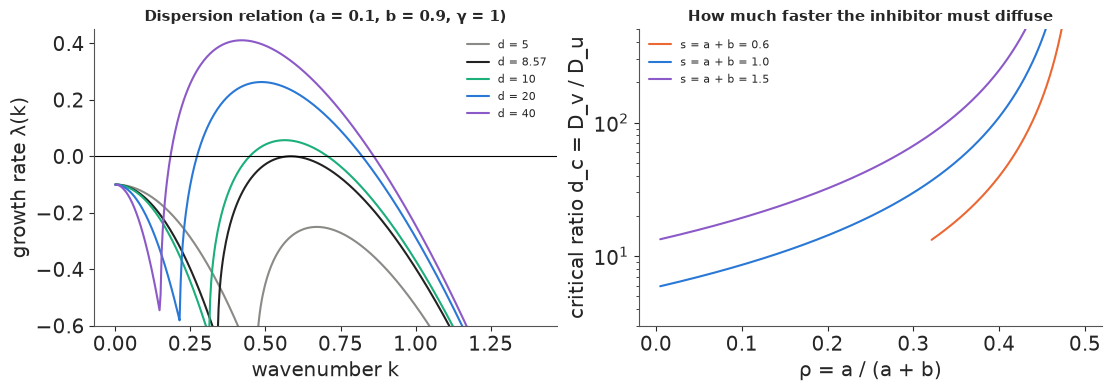

In [2]:
def jacobian(s, rho):
    """Schnakenberg Jacobian entries at the uniform steady state (s = a + b, rho = a / s)."""
    return 1 - 2 * rho, s**2, -2 * (1 - rho), -s**2


def growth_rate(q, s, rho, d, g):
    """Largest real part of the eigenvalues of gamma*J - q*diag(1, d); q = k^2 (broadcasts)."""
    fu, fv, gu, gv = jacobian(s, rho)
    a11, a22 = g * fu - q, g * gv - d * q
    tr, det = a11 + a22, a11 * a22 - g**2 * fv * gu
    disc = tr**2 / 4 - det
    return tr / 2 + np.sqrt(np.maximum(disc, 0))


def d_critical(s, rho):
    """Smallest diffusion ratio for a Turing instability (inf if the activator does not self-activate)."""
    fu = 1 - 2 * rho
    with np.errstate(divide="ignore", invalid="ignore"):
        dc = s**2 * ((1 + np.sqrt(2 - 2 * rho)) / fu) ** 2
    return np.where(fu > 0, dc, np.inf)


def is_turing(s, rho, d):
    return (1 - 2 * rho < s**2) & (d > d_critical(s, rho))


Q_GRID = np.linspace(1e-4, 3.0, 600)


def fastest_mode(s, rho, d, g, chunk=5000):
    """Wavenumber k_m of the fastest-growing mode and its growth rate, for arrays of parameters."""
    s, rho, d, g = (np.atleast_1d(np.asarray(x, float)) for x in (s, rho, d, g))
    km, lm = [], []
    for i in range(0, len(s), chunk):
        sl = slice(i, i + chunk)
        lam = growth_rate(Q_GRID[None, :], s[sl, None], rho[sl, None], d[sl, None], g[sl, None])
        j = lam.argmax(axis=1)
        km.append(np.sqrt(Q_GRID[j]))
        lm.append(lam.max(axis=1))
    return np.concatenate(km), np.concatenate(lm)


TRUE = dict(s=1.0, rho=0.1, d=20.0, g=1.0)     # a = 0.1, b = 0.9
print(f"d_c for s = 1, rho = 0.1: {d_critical(1.0, 0.1):.2f}")
km_true, lm_true = fastest_mode(**TRUE)
print(f"truth (d = 20): fastest mode k_m = {km_true[0]:.3f}, wavelength {2 * np.pi / km_true[0]:.1f}, "
      f"growth rate {lm_true[0]:.3f}")

kk = np.linspace(0, 1.4, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for d_, c in zip([5.0, 8.57, 10.0, 20.0, 40.0], [GREY, INK, AQUA, BLUE, PURPLE]):
    axes[0].plot(kk, growth_rate(kk**2, 1.0, 0.1, d_, 1.0), color=c, label=f"d = {d_:g}")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set(ylim=(-0.6, 0.45), xlabel="wavenumber k", ylabel="growth rate λ(k)",
            title="Dispersion relation (a = 0.1, b = 0.9, γ = 1)")
axes[0].legend(fontsize=8)
rr = np.linspace(0.005, 0.495, 300)
for s_, c in zip([0.6, 1.0, 1.5], [ORANGE, BLUE, PURPLE]):
    dc = d_critical(s_, rr)
    dc = np.where(1 - 2 * rr < s_**2, dc, np.nan)
    axes[1].plot(rr, dc, color=c, label=f"s = a + b = {s_}")
axes[1].set(yscale="log", ylim=(3, 500), xlabel="ρ = a / (a + b)", ylabel="critical ratio d_c = D_v / D_u",
            title="How much faster the inhibitor must diffuse")
axes[1].legend(fontsize=8);

**Left:** below $d_c = 8.6$ every mode decays ($\lambda < 0$ for all $k$). At $d_c$ one wavenumber
becomes marginal, and above it a band of wavenumbers grows. At $d = 20$ the band runs from about
$k = 0.25$ to $0.85$ and the fastest mode is $k_m \approx 0.49$, a wavelength of about 13 units. The
$k = 0$ mode always decays: without diffusion the chemistry is stable. **Right:** the critical ratio
grows without bound as $\rho \to 1/2$ (the activator's self-enhancement vanishes) and is never below
about 5.8 in this model. Diffusion coefficients of similar-sized proteins rarely differ by an order of
magnitude, which is the classic objection to Turing mechanisms in development; we return to it in
section 5.

## 2 · Growing a pattern: a semi-implicit spectral solver

On a periodic square, the Laplacian is diagonal in Fourier space ($\nabla^2 \to -k^2$). Treating
diffusion implicitly and the reactions explicitly gives the update

$$\hat u^{\,n+1} = \frac{\widehat{u^n + \Delta t\, f(u^n, v^n)}}{1 + \Delta t\, k^2}, \qquad
  \hat v^{\,n+1} = \frac{\widehat{v^n + \Delta t\, g(u^n, v^n)}}{1 + \Delta t\, d\, k^2},$$

two real FFTs per field per step. It is unconditionally stable for the (stiff) diffusion part; the step
is limited only by the reactions. A 128 × 128 grid on a square of side $L = 100$ runs about 4,000 steps
a second. We start from the uniform state plus white noise of standard deviation $10^{-3}$ in both
species, which stands in for molecular noise.

three simulations: 5.6 s
final pattern (d = 20): wavelength 11.35; linear theory 2*pi/k_m = 12.95; ratio 0.877
stripes (d = 10): wavelength 10.98, linear theory 11.10


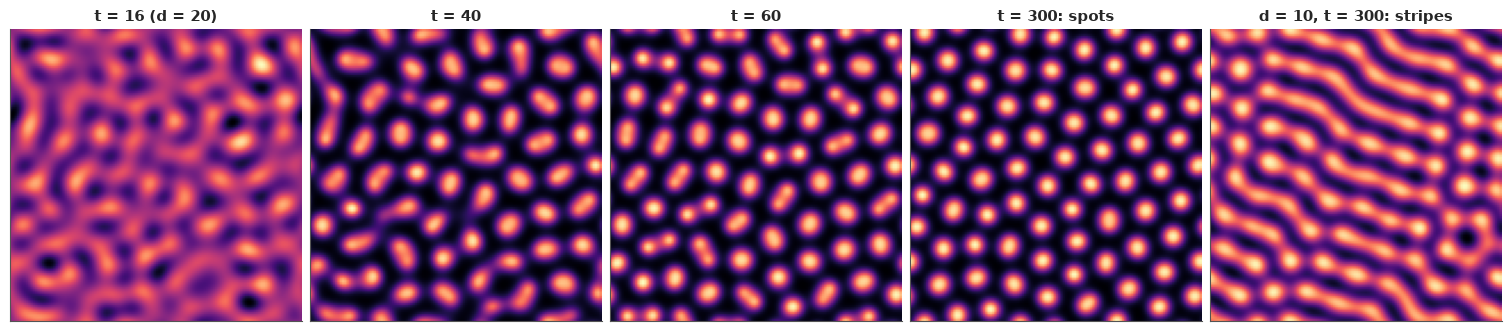

In [3]:
N_GRID, L_BOX = 128, 100.0
KX = 2 * np.pi * np.fft.fftfreq(N_GRID, L_BOX / N_GRID)
KY = 2 * np.pi * np.fft.rfftfreq(N_GRID, L_BOX / N_GRID)
K2 = KX[:, None] ** 2 + KY[None, :] ** 2          # rfft2 layout: (128, 65)


def initial_state(s, rho, s0=1e-3, seed=0):
    r = np.random.default_rng(seed)
    a, b = rho * s, (1 - rho) * s
    return (s + s0 * r.standard_normal((N_GRID, N_GRID)),
            b / s**2 + s0 * r.standard_normal((N_GRID, N_GRID)))


def simulate(state, s, rho, d, g, t_end, dt=None, snaps=()):
    """Semi-implicit spectral integration from `state` for t_end; returns (u, v) and {t: u} snapshots."""
    a, b = rho * s, (1 - rho) * s
    dt = dt or min(0.025, 0.1 / (g * (1 + s**2)))
    n = int(round(t_end / dt))
    iu, iv = 1 / (1 + dt * K2), 1 / (1 + dt * d * K2)
    want = {int(round(t / dt)): t for t in snaps}
    u, v = state
    out = {}
    for i in range(1, n + 1):
        uuv = u * u * v
        u = np.fft.irfft2(np.fft.rfft2(u + dt * g * (a - u + uuv)) * iu, s=u.shape)
        v = np.fft.irfft2(np.fft.rfft2(v + dt * g * (b - uuv)) * iv, s=v.shape)
        if i in want:
            out[want[i]] = u.copy()
    return (u, v), out


SHELL = np.rint(np.sqrt(K2) / (2 * np.pi / L_BOX)).astype(int)     # |k| in units of 2*pi/L


def radial_spectrum(u):
    """Radially averaged power spectrum of an image, by integer wavenumber shell."""
    p = np.abs(np.fft.rfft2(u - u.mean())) ** 2
    p[:, 1:N_GRID // 2] *= 2
    return np.bincount(SHELL.ravel(), p.ravel()) / np.maximum(np.bincount(SHELL.ravel()), 1)


def pattern_wavelength(u):
    """Wavelength of the spectral peak (parabolic interpolation in log power)."""
    sp = radial_spectrum(u)[: N_GRID // 2]
    sp[0] = 0
    i = int(np.argmax(sp))
    y0, y1, y2 = np.log(sp[i - 1:i + 2] + 1e-30)
    return L_BOX / (i + 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2))


t0 = time.time()
T_EARLY = (4.0, 8.0, 12.0, 16.0)
state0 = initial_state(TRUE["s"], TRUE["rho"], seed=1)
state, early = simulate(state0, **TRUE, t_end=16.0, dt=0.005, snaps=T_EARLY)
state, late = simulate(state, **TRUE, t_end=284.0, snaps=(24.0, 44.0))
u_final = state[0]
(u_stripes, _), _ = simulate(initial_state(1.0, 0.1, seed=2), 1.0, 0.1, 10.0, 1.0, t_end=300.0)
print(f"three simulations: {time.time() - t0:.1f} s")
W_OBS = pattern_wavelength(u_final)
print(f"final pattern (d = 20): wavelength {W_OBS:.2f}; linear theory 2*pi/k_m = "
      f"{2 * np.pi / km_true[0]:.2f}; ratio {W_OBS / (2 * np.pi / km_true[0]):.3f}")
print(f"stripes (d = 10): wavelength {pattern_wavelength(u_stripes):.2f}, linear theory "
      f"{2 * np.pi / fastest_mode(1.0, 0.1, 10.0, 1.0)[0][0]:.2f}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3.4))
panels = [(early[16.0], "t = 16 (d = 20)"), (late[24.0], "t = 40"), (late[44.0], "t = 60"),
          (u_final, "t = 300: spots"), (u_stripes, "d = 10, t = 300: stripes")]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, cmap="magma", extent=(0, L_BOX, 0, L_BOX))
    ax.set(title=title, xticks=[], yticks=[])
    ax.grid(False);

Activator concentration $u$ at five moments. At $t = 16$ the field still looks like smoothed noise
(its range is only about ±2% around $u^* = 1$): all the modes in the unstable band are growing
together, each from its own random start. By $t = 40$ the fastest modes dominate and the peaks have
begun to saturate; by $t = 60$ the spots have formed, and afterwards they shift slowly into a nearly
hexagonal arrangement. With the same kinetics but $d = 10$, just above $d_c = 8.6$, the pattern is
**stripes** (labyrinths in general): near onset the quadratic interactions between modes that favour
spots are weak. So the same chemistry makes spots or stripes depending on one diffusion ratio. Nothing
in the model marks where a spot should be; their positions come from the noise, their spacing from
the dispersion relation.

## 3 · What a finished pattern can tell you

Suppose all we have is a picture of the settled pattern. It is tempting to fit the PDE to the image
pixel by pixel, but that is hopeless and wrong: the spots' positions are set by the initial noise,
which we do not know, so any small change in parameters or noise moves every spot. What a steady
pattern reliably reports is its **statistics**: the wavelength (the peak of the radially averaged
power spectrum, or equivalently the spot density), whether it is spots or stripes, and the contrast.
Contrast needs calibrated concentrations, which fluorescence images seldom give, so we use the
wavelength alone and ask what it identifies.

**A feature likelihood needs a forward model for the feature.** Linear theory predicts the
wavelength $2\pi/k_m$ of the fastest-growing mode, but the settled pattern is shaped by nonlinear
selection too. So we calibrate: simulate settled patterns for random parameter sets that satisfy the
Turing conditions and compare the measured wavelength with the linear prediction.

In [4]:
def prior_draws(n, r):
    """Prior for Part A: s = a + b, rho = a / (a + b), diffusion ratio d, reaction scale gamma."""
    return dict(s=r.lognormal(0.0, 0.5, n), rho=r.beta(2.0, 5.0, n),
                d=r.lognormal(np.log(10), 1.0, n), g=r.lognormal(0.0, 0.7, n))


rcal = np.random.default_rng(611)
cand = prior_draws(3000, rcal)
km_c, lm_c = fastest_mode(**cand)
wl_c = 2 * np.pi / km_c
use = np.where(is_turing(cand["s"], cand["rho"], cand["d"]) & (lm_c > 0.03) & (wl_c > 7) & (wl_c < 25))[0][:10]
t0 = time.time()
ratios = []
for i in use:
    p = {k: cand[k][i] for k in cand}
    (u_i, _), _ = simulate(initial_state(p["s"], p["rho"], seed=int(i)), **p, t_end=300.0)
    ratios.append(pattern_wavelength(u_i) / wl_c[i])
ratios = np.array(ratios)
C_MU, C_SD = np.log(ratios).mean(), np.log(ratios).std(ddof=1)
print(f"{len(use)} calibration patterns in {time.time() - t0:.0f} s; "
      f"measured / linear wavelength: {np.round(ratios, 2)}")
print(f"log ratio: mean {C_MU:.3f} (factor {np.exp(C_MU):.3f}), sd {C_SD:.3f}")

10 calibration patterns in 30 s; measured / linear wavelength: [0.88 0.9  0.93 0.97 0.95 0.87 0.9  0.97 1.04 0.88]
log ratio: mean -0.076 (factor 0.927), sd 0.056


Settled patterns are usually **shorter** than the linear prediction, by about 7% on average (ratios
from 0.87 to 1.04), with a scatter of about 6% between parameter sets. Nonlinear selection prefers a wavenumber
above $k_m$ here, and the periodic box can only hold whole numbers of wavelengths. We fold both into
the feature likelihood:

$$\log w_{\text{obs}} \sim \mathcal{N}\!\left(\log \frac{2\pi}{k_m(\theta)} + c,\ \sigma_c\right),$$

with $c$ and $\sigma_c$ the calibration mean and sd, restricted to parameters that satisfy the Turing
conditions (we saw a pattern, so the uniform state must be unstable). With only four parameters and a
one-dimensional feature, the posterior is easy to get by **importance sampling from the prior**: draw
200,000 parameter sets, weight each by the likelihood, and check the effective sample size. This is
the same computation that ABC or `pm.Simulator` would do, minus the simulations, because the
calibrated linear theory replaces the simulator.

In [5]:
r_is = np.random.default_rng(612)
pri = prior_draws(200_000, r_is)
km_p, _ = fastest_mode(**pri)
turing_p = is_turing(pri["s"], pri["rho"], pri["d"])
logw = np.where(turing_p, -0.5 * ((np.log(W_OBS) - np.log(2 * np.pi / km_p) - C_MU) / C_SD) ** 2, -np.inf)
w_is = np.exp(logw - logw.max())
w_is /= w_is.sum()
ess_is = 1 / np.sum(w_is**2)
snap_idx = r_is.choice(len(w_is), 4000, p=w_is)
snap = {k: v[snap_idx] for k, v in pri.items()}
print(f"prior probability of a Turing instability: {turing_p.mean():.3f}")
print(f"importance sampling ESS: {ess_is:.0f} of {len(w_is)}")
for k in ["s", "rho", "d", "g"]:
    q_pr, q_po = np.quantile(pri[k], [0.05, 0.95]), np.quantile(snap[k], [0.05, 0.95])
    print(f"  {k:>4}: prior 90% [{q_pr[0]:.3g}, {q_pr[1]:.3g}]   snapshot posterior [{q_po[0]:.3g}, "
          f"{q_po[1]:.3g}]   truth {TRUE[k]}")

prior probability of a Turing instability: 0.113
importance sampling ESS: 4285 of 200000
     s: prior 90% [0.437, 2.27]   snapshot posterior [0.731, 1.7]   truth 1.0
   rho: prior 90% [0.0625, 0.583]   snapshot posterior [0.0439, 0.311]   truth 0.1
     d: prior 90% [1.93, 51.9]   snapshot posterior [11, 83.4]   truth 20.0
     g: prior 90% [0.319, 3.15]   snapshot posterior [0.771, 2.09]   truth 1.0


The wavelength (about 11.4 units, observed without noise here) narrows the prior only a little in any
single parameter. The prior probability of a Turing instability is about one in nine under these
priors (0.11), and conditioning on "there is a pattern" alone pushes $d$ up and $\rho$ down. The
rest of what
the wavelength says is a single **combination** of parameters: $k_m \propto \sqrt{\gamma}$ times a
function of $(s, \rho, d)$, so a fast-reacting system with one diffusion ratio and a slower one with
another give the same spacing. The figure in section 4 shows this ridge.

## 4 · Watching the pattern grow: an exact likelihood from mode growth

The early images carry much more information, and they come with an exact likelihood. While the
perturbation is small, the dynamics are **linear**, so every Fourier mode evolves independently:

$$\begin{pmatrix}\hat u_{\mathbf k}(t) \\ \hat v_{\mathbf k}(t)\end{pmatrix} = e^{A(k)t}
  \begin{pmatrix}\hat u_{\mathbf k}(0) \\ \hat v_{\mathbf k}(0)\end{pmatrix}.$$

White initial noise of variance $s_0^2$ gives independent complex Gaussian Fourier coefficients
(normalising the FFT by the number of pixels' square root), and a linear map of Gaussians is Gaussian.
If we image only the activator at times $t_1, \dots, t_T$ with white camera noise of variance
$\sigma^2$, the vector $x_{\mathbf k} = (\hat u_{\mathbf k}(t_1), \dots, \hat u_{\mathbf k}(t_T))$ is complex
Gaussian with covariance

$$C(k) = s_0^2\, U U^\top + \sigma^2 I, \qquad U_{i\cdot} = \text{first row of } e^{A(k) t_i},$$

and modes with different $\mathbf k$ are independent. The log-likelihood is
$\sum_{\mathbf k} \left[-\log\det C(k) - x_{\mathbf k}^H C(k)^{-1} x_{\mathbf k}\right]$. Two exact
simplifications make it cheap:

- **Sufficient statistics.** $C$ depends only on $k^2$, so the modes can be grouped by their integer
  $k^2$ (in units of $(2\pi/L)^2$) and only the summed outer products $S(k) = \sum x x^H$ are needed.
- **Woodbury.** $C$ is rank 2 plus a diagonal, so with $H = I_2 + (s_0^2/\sigma^2) U^\top U$,
  $\det C = \sigma^{2T}\det H$ and $\operatorname{tr}(C^{-1}S) = \sigma^{-2}\left[\operatorname{tr} S
  - (s_0^2/\sigma^2)\operatorname{tr}(H^{-1} U^\top S U)\right]$: only 2 × 2 algebra per wavenumber.
  The first try, a batched 4 × 4 Cholesky, was 10 times slower to sample.

The 2 × 2 matrix exponential has a closed form: with $\tau = \operatorname{tr}A/2$ and
$q = \tau^2 - \det A$, $e^{At} = e^{\tau t}[\cosh(\sqrt q\, t) I + \sinh(\sqrt q\, t)(A - \tau I)/\sqrt q]$,
with cos/sin when $q < 0$. We write the hyperbolic case as $(e^{(\tau + \sqrt q)t} \pm e^{(\tau - \sqrt q)t})/2$
so that heavily damped high-$k$ modes do not overflow, and guard both square roots so that
`pt.switch` never differentiates a NaN.

The data: the four early images at $t = 4, 8, 12, 16$ of the simulation in section 2 (simulated with a
fine step, $\Delta t = 0.005$, so that time-stepping error is negligible), plus camera noise of
sd $5 \times 10^{-4}$. We keep wavenumbers with $k^2 < 1.5$; above that, every mode has decayed below
the noise within the first image and carries no information about the kinetics.

In [6]:
SIGMA_CAM = 5e-4
r_cam = np.random.default_rng(613)
imgs = [early[t] + SIGMA_CAM * r_cam.standard_normal((N_GRID, N_GRID)) for t in T_EARLY]
coef = np.stack([np.fft.rfft2(im) / N_GRID for im in imgs])          # (T, 128, 65), E|x|^2 = variance
m_int = (np.fft.fftfreq(N_GRID) * N_GRID)[:, None] ** 2 + np.arange(N_GRID // 2 + 1)[None, :] ** 2
inner = np.zeros(m_int.shape, bool)
inner[:, 1:N_GRID // 2] = True               # columns without a conjugate partner inside the half-plane
k2_int, grp = np.unique(m_int[inner].astype(int), return_inverse=True)
X = coef[:, inner]
nT = len(T_EARLY)
S_all = np.zeros((len(k2_int), nT, nT))
for i in range(nT):
    for j in range(nT):
        S_all[:, i, j] = np.bincount(grp, np.real(X[i] * np.conj(X[j])), minlength=len(k2_int))
n_all = np.bincount(grp, minlength=len(k2_int)).astype(float)
q_all = k2_int * (2 * np.pi / L_BOX) ** 2
keep = q_all < 1.5
q_fit, S_fit, n_fit = q_all[keep], S_all[keep], n_all[keep]
print(f"{int(n_all.sum())} independent Fourier modes, {len(k2_int)} distinct k^2; "
      f"fitting {int(n_fit.sum())} modes in {keep.sum()} groups (k^2 < 1.5)")
print("image sd at t = 4, 8, 12, 16:", [f"{im.std():.4f}" for im in imgs])

8064 independent Fourier modes, 1618 distinct k^2; fitting 581 modes in 138 groups (k^2 < 1.5)
image sd at t = 4, 8, 12, 16: ['0.0006', '0.0010', '0.0024', '0.0062']


In [7]:
def expm2(a11, a12, a21, a22, t):
    """exp(A t) for a batch of 2x2 matrices, overflow-safe and NaN-free in both branches."""
    tau = (a11 + a22) / 2
    q = tau**2 - (a11 * a22 - a12 * a21)
    rq = pt.sqrt(pt.maximum(q, 1e-12))
    wq = pt.sqrt(pt.maximum(-q, 1e-12))
    ep, em = pt.exp((tau + rq) * t), pt.exp((tau - rq) * t)
    c = pt.switch(q > 0, (ep + em) / 2, pt.exp(tau * t) * pt.cos(wq * t))
    sh = pt.switch(q > 0, (ep - em) / (2 * rq), pt.exp(tau * t) * pt.sin(wq * t) / wq)
    return c + sh * (a11 - tau), sh * a12, sh * a21, c + sh * (a22 - tau)


with pm.Model() as turing_model:
    s = pm.LogNormal("s", 0.0, 0.5)
    rho = pm.Beta("rho", 2.0, 5.0)
    d = pm.LogNormal("d", np.log(10), 1.0)
    g = pm.LogNormal("g", 0.0, 0.7)
    s0 = pm.LogNormal("s0", np.log(1e-3), 1.5)
    sig = pm.LogNormal("sigma", np.log(1e-3), 1.5)
    pm.Deterministic("a", rho * s)
    pm.Deterministic("b", (1 - rho) * s)
    fu, fv, gu, gv = 1 - 2 * rho, s**2, -2 * (1 - rho), -(s**2)
    ones = pt.ones_like(q_fit)
    # U[i] = first row of exp(A t_i): response of u(t_i) to initial u and initial v
    U = [expm2(g * fu - q_fit, g * fv * ones, g * gu * ones, g * gv - d * q_fit, t)[:2] for t in T_EARLY]
    r = s0**2 / sig**2
    G00 = sum(u0 * u0 for u0, _ in U)
    G01 = sum(u0 * u1 for u0, u1 in U)
    G11 = sum(u1 * u1 for _, u1 in U)
    H00, H01, H11 = 1 + r * G00, r * G01, 1 + r * G11
    detH = H00 * H11 - H01**2
    W = [[sum(U[i][p] * S_fit[:, i, j] * U[j][p2] for i in range(nT) for j in range(nT))
          for p2 in range(2)] for p in range(2)]
    tr_HinvW = (H11 * W[0][0] - H01 * (W[0][1] + W[1][0]) + H00 * W[1][1]) / detH
    tr_S = sum(S_fit[:, i, i] for i in range(nT))
    logdet = nT * pt.log(sig**2) + pt.log(detH)
    quad = (tr_S - r * tr_HinvW) / sig**2
    pm.Potential("mode_growth", pt.sum(-n_fit * logdet - quad))

    t0 = time.time()
    idata_t = pm.sample(tune=1500, target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
    t_turing = time.time() - t0
sum_t = report(idata_t, ["s", "rho", "d", "g", "s0", "sigma"], "mode-growth fit", t_turing)
print(az.summary(idata_t, var_names=["a", "b", "d", "g", "s0", "sigma"], round_to=4)
      [["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]])

mode-growth fit: 90 s, 0 divergences, max r_hat 1.012, min bulk ESS 584, warm-up 1500 steps
          mean      sd  eti89_lb  eti89_ub   ess_bulk   r_hat
a       0.0960  0.0243    0.0544    0.1330   589.4864  1.0066
b       0.9383  0.0608    0.8434    1.0358   547.1988  1.0128
d      21.0113  2.3735   17.7008   25.2275   722.3613  1.0066
g       0.9870  0.0566    0.8993    1.0803   586.1164  1.0082
s0      0.0010  0.0000    0.0009    0.0010  1958.5790  1.0025
sigma   0.0005  0.0000    0.0005    0.0005  3377.6778  1.0023


The first attempt used nutpie's low-rank mass-matrix adaptation, which usually helps with correlated
parameters: about 130-160 divergences ("large energy error") and $\hat r$ up to 1.8. The posterior is
curved rather than linearly correlated (the data pin down entries of $\gamma J$, and $\gamma$, $s$,
$\rho$ enter them as products and differences). The default diagonal adaptation with
`target_accept=0.95` and 1,500 warm-up steps samples cleanly: 0 divergences, $\hat r \le 1.013$,
bulk ESS above 500, in about 90 s.

Four noisy images of what still looks like smoothed noise recover **all four kinetic parameters**:
$d$ within about ±12% (89% interval 17.7-25.2, truth 20), $\gamma$ within about ±9% (0.90-1.08, truth
1), $b$ (0.84-1.04, truth 0.9) and, less precisely, $a$ (0.054-0.133, truth 0.1). The initial noise
$s_0$ and camera noise $\sigma$ come out at their true values. The likelihood is exact for the
linearised dynamics, and the images were taken while the field was within about ±2% of the uniform
state, so the linearisation holds; the fine simulation step keeps time-stepping error negligible.

    early images: fastest growth rate 90% [0.262, 0.264], its wavenumber [0.488, 0.488]  (truth 0.263 at 0.485)
 settled pattern: fastest growth rate 90% [0.014, 0.650], its wavenumber [0.464, 0.560]  (truth 0.263 at 0.485)


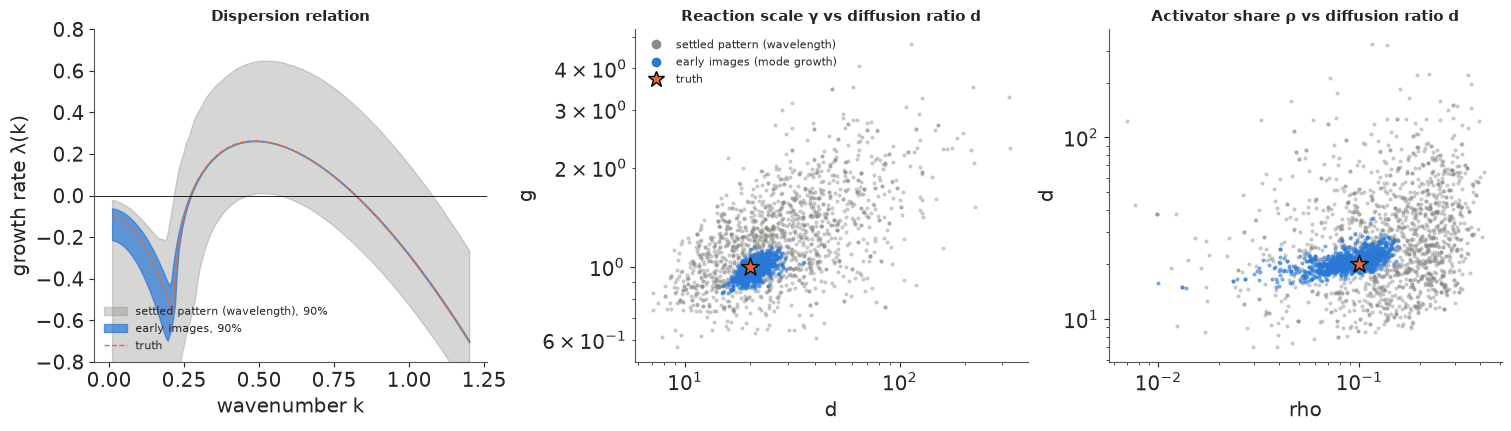

In [8]:
post_t = az.extract(idata_t, var_names=["s", "rho", "d", "g"], num_samples=1000, random_seed=RANDOM_SEED)
pt_draws = {k: post_t[k].values for k in ["s", "rho", "d", "g"]}
kq = np.linspace(0.01, 1.2, 200)
lam_early = growth_rate(kq[None, :] ** 2, *(pt_draws[k][:, None] for k in ["s", "rho", "d", "g"]))
sub = r_is.choice(len(snap["s"]), 1000, replace=False)
lam_snap = growth_rate(kq[None, :] ** 2, *(snap[k][sub, None] for k in ["s", "rho", "d", "g"]))

for arr, lab in [(lam_early, "early images"), (lam_snap, "settled pattern")]:
    q_l = np.quantile(arr.max(axis=1), [0.05, 0.95])
    q_k = np.quantile(kq[arr.argmax(axis=1)], [0.05, 0.95])
    print(f"{lab:>16}: fastest growth rate 90% [{q_l[0]:.3f}, {q_l[1]:.3f}], "
          f"its wavenumber [{q_k[0]:.3f}, {q_k[1]:.3f}]  (truth {lm_true[0]:.3f} at {km_true[0]:.3f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
for arr, c, lab, al in [(lam_snap, GREY, "settled pattern (wavelength)", 0.35), (lam_early, BLUE, "early images", 0.7)]:
    lo, hi = np.quantile(arr, [0.05, 0.95], axis=0)
    ax.fill_between(kq, lo, hi, color=c, alpha=al, label=f"{lab}, 90%")
ax.plot(kq, growth_rate(kq**2, **TRUE), color=ORANGE, lw=1, ls="--", label="truth")
ax.axhline(0, color="k", lw=0.6)
ax.set(ylim=(-0.8, 0.8), xlabel="wavenumber k", ylabel="growth rate λ(k)", title="Dispersion relation")
ax.legend(fontsize=8, loc="lower left")
for ax, (xk, yk) in zip(axes[1:], [("d", "g"), ("rho", "d")]):
    ax.scatter(snap[xk][:1500], snap[yk][:1500], s=4, color=GREY, alpha=0.35, label="settled pattern")
    ax.scatter(pt_draws[xk], pt_draws[yk], s=4, color=BLUE, alpha=0.5, label="early images")
    ax.scatter([TRUE[xk]], [TRUE[yk]], marker="*", s=180, color=ORANGE, edgecolor="k", zorder=5,
               label="truth")
    ax.set(xscale="log", yscale="log", xlabel=xk, ylabel=yk)
handles = [plt.Line2D([], [], marker="o", ls="", color=GREY, label="settled pattern (wavelength)"),
           plt.Line2D([], [], marker="o", ls="", color=BLUE, label="early images (mode growth)"),
           plt.Line2D([], [], marker="*", ls="", ms=12, color=ORANGE, mec="k", label="truth")]
axes[1].legend(handles=handles, fontsize=8)
axes[1].set_title("Reaction scale γ vs diffusion ratio d")
axes[2].set_title("Activator share ρ vs diffusion ratio d");

**Left:** the dispersion relation implied by each posterior (90% bands) against the truth
(dashed). The settled pattern's wavelength constrains only where the fastest mode sits (its
wavenumber to 0.46-0.56, truth 0.485); its growth rate (anywhere from 0.01 to 0.65), the width of the
unstable band and the behaviour at small $k$ are almost free (grey). The early images pin the unstable
band: the fastest growth rate to 0.262-0.264 (truth 0.263). Only the damped modes at small $k$,
whose signal sinks below the camera noise within the first images, stay uncertain (blue, left).
**Middle and right:** posterior draws of pairs of parameters. The wavelength-only posterior (grey) is
a broad cloud along ridges: larger $d$ with larger $\gamma$, larger $d$ with larger $\rho$ give
similar spacings. The mode-growth posterior (blue) is a small blob around the truth, elongated only
along $\rho$ (the activator's direct supply $a$ is the least well determined parameter).

The lesson is general: **a steady state reports a length scale; the approach to it reports rates**.
E50 found the same for a morphogen gradient, whose steady profile identified only $\sqrt{D/k}$ until
FRAP added a time scale. For patterns, filming their onset (or perturbing a settled pattern and
watching it recover) is the rate experiment, and in the linear regime it comes with an exact
Gaussian likelihood in Fourier space: no simulator, no summary statistics, no ABC tolerance.

## 5 · Is it Turing? Nodal and Lefty, and the size of Turing space

**The Nodal/Lefty debate.** In zebrafish embryos, the signalling protein Nodal activates its own
expression and that of its inhibitor Lefty, the textbook arrangement of an activator-inhibitor
system. Müller et al. (2012, *Science* 336:721) measured the proteins' effective diffusion coefficients
by FRAP and found that the Leftys diffuse much faster than the Nodals, as Turing's recipe requires
(E50, section 7, fits a FRAP experiment). The values, as quoted by Kuhn et al. (2022, *Nature
Communications*), are (µm²/s):

| protein | Cyclops (Nodal) | Squint (Nodal) | Lefty1 | Lefty2 |
|---|---|---|---|---|
| effective $D$ | 0.7 ± 0.2 | 3.2 ± 0.5 | 11.1 ± 0.6 | 18.9 ± 3.0 |

(TRANSCRIBED; we treat the ± as one standard error.) Is the ratio large **enough**? The answer
depends on the reaction kinetics too, and those are poorly known. For a generic activator-inhibitor
pair with Jacobian $J = \begin{pmatrix} f_u & f_v \\ g_u & g_v\end{pmatrix}$ ($f_u > 0$, $f_v < 0$,
$g_u > 0$, $g_v < 0$) the critical ratio from section 1 can be written in two dimensionless numbers:

- $\varphi = f_u / |g_v| \in (0, 1)$: net self-activation of the activator relative to the
  inhibitor's clearance (stability without diffusion requires $\varphi < 1$; Müller et al.
  reported similar clearance rates for Nodals and Leftys);
- $e = \det J / (f_u |g_v|) > 0$: how much the inhibition loop exceeds the minimum needed for the
  uniform state to be stable.

Then $\det J = f_u |g_v|\, e$ and $d_c = \big(\sqrt{e} + \sqrt{1 + e}\big)^2 / \varphi$. Weak
self-activation or a strong inhibition loop both raise the bar. We know neither, so we give them priors
($\varphi \sim \text{Beta}(2, 2)$, $e \sim \text{LogNormal}(0, 1)$), fit the four diffusion
coefficients to their measurements, and compute the posterior probability that $D_{\text{Lefty}} /
D_{\text{Nodal}} > d_c$ for each pair. No data touch $\varphi$ and $e$, so their posterior is their
prior: the answer is honest about how much it rests on assumptions.

In [9]:
D_OBS = np.array([0.7, 3.2, 11.1, 18.9])
D_SE = np.array([0.2, 0.5, 0.6, 3.0])
proteins = ["Cyclops", "Squint", "Lefty1", "Lefty2"]
with pm.Model(coords={"protein": proteins}) as nodal_model:
    D = pm.LogNormal("D", np.log(3.0), 2.0, dims="protein")
    pm.Normal("D_hat", D, D_SE, observed=D_OBS, dims="protein")
    phi = pm.Beta("phi", 2.0, 2.0)
    e_loop = pm.LogNormal("e", 0.0, 1.0)
    pm.Deterministic("d_c", (pt.sqrt(e_loop) + pt.sqrt(1 + e_loop)) ** 2 / phi)
    idata_n = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
report(idata_n, ["D", "phi", "e"], "Nodal/Lefty")
pn = az.extract(idata_n, var_names=["D", "d_c"])
Dd, dc_draws = pn["D"].values, pn["d_c"].values
pairs = [("Lefty1", "Cyclops"), ("Lefty2", "Cyclops"), ("Lefty1", "Squint"), ("Lefty2", "Squint")]
print(f"prior median of d_c: {np.median(dc_draws):.1f} (90%: {np.quantile(dc_draws, 0.05):.1f}-"
      f"{np.quantile(dc_draws, 0.95):.0f})")
p_turing = {}
for inh, act in pairs:
    ratio = Dd[proteins.index(inh)] / Dd[proteins.index(act)]
    p_turing[f"{inh}/{act}"] = (ratio > dc_draws).mean()
    print(f"{inh:>6}/{act:<7}: ratio median {np.median(ratio):5.1f} "
          f"(90% {np.quantile(ratio, 0.05):4.1f}-{np.quantile(ratio, 0.95):5.1f}), "
          f"P(ratio > d_c) = {p_turing[f'{inh}/{act}']:.2f}")

Nodal/Lefty: 0 divergences, max r_hat 1.003, min bulk ESS 2880, warm-up 400 steps
prior median of d_c: 13.4 (90%: 3.9-76)
Lefty1/Cyclops: ratio median  16.7 (90% 10.9- 33.7), P(ratio > d_c) = 0.60
Lefty2/Cyclops: ratio median  27.5 (90% 16.2- 58.2), P(ratio > d_c) = 0.76
Lefty1/Squint : ratio median   3.5 (90%  2.8-  4.9), P(ratio > d_c) = 0.04
Lefty2/Squint : ratio median   5.8 (90%  4.0-  8.6), P(ratio > d_c) = 0.17


With these priors, the critical ratio has a median of about 13 and a long right tail (90%
interval 4-76). The Cyclops pairs clear it more often than not: $P(D_{\text{Lefty2}}/D_{\text{Cyclops}}
> d_c) \approx 0.76$, and 0.60 for Lefty1. The Squint pairs, whose ratios are only about 3.5 and 6,
mostly do not (0.04 and 0.17). Measurement error in the $D$s matters for the Cyclops pairs (Cyclops'
$D = 0.7 \pm 0.2$ spreads the ratio over a factor of about three between its 5% and 95% points),
but the dominant uncertainty is
the kinetics. So the honest summary of "are the diffusivities different enough for a Turing
instability?" is: **for Cyclops probably, for Squint probably not, and mainly it depends on reaction
rates nobody has measured**. That is a statement about a linear instability only; whether a
zebrafish embryo actually forms a periodic pattern is a different question (it forms a graded domain of
Nodal signalling at the margin, and Müller et al. presented Nodal/Lefty as a reaction-diffusion
system with differential diffusivity, not as a demonstration of periodic Turing patterns).

**The size of Turing space.** How special must parameters be for a pattern to form at all? Under the
Schnakenberg priors of section 3, we can compute the fraction of parameter space that is Turing
unstable exactly (the conditions are closed-form), as a function of the diffusion ratio.

d =   5: Schnakenberg Turing fraction 0.000, generic activator-inhibitor 0.104
d =  10: Schnakenberg Turing fraction 0.047, generic activator-inhibitor 0.379
d =  20: Schnakenberg Turing fraction 0.203, generic activator-inhibitor 0.659
d =  50: Schnakenberg Turing fraction 0.402, generic activator-inhibitor 0.903
d = 100: Schnakenberg Turing fraction 0.505, generic activator-inhibitor 0.966


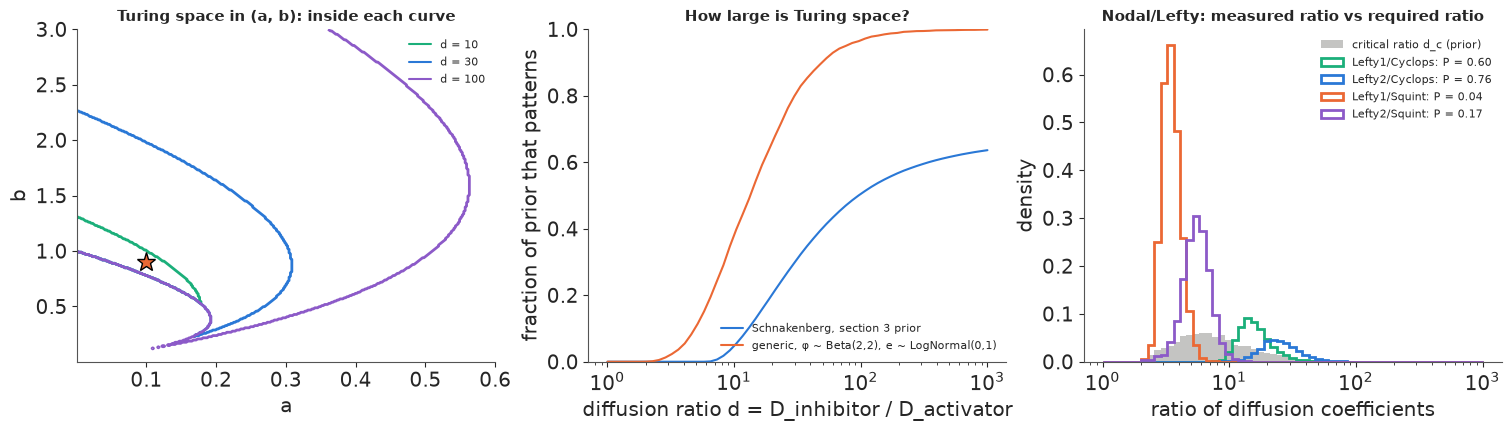

In [10]:
r_ts = np.random.default_rng(614)
kin = prior_draws(400_000, r_ts)
d_grid = np.geomspace(1, 1000, 60)
frac_schnak = [is_turing(kin["s"], kin["rho"], dd).mean() for dd in d_grid]
frac_generic = [(dc_draws < dd).mean() for dd in d_grid]
for dd in [5, 10, 20, 50, 100]:
    print(f"d = {dd:>3}: Schnakenberg Turing fraction {is_turing(kin['s'], kin['rho'], dd).mean():.3f}, "
          f"generic activator-inhibitor {(dc_draws < dd).mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
A_, B_ = np.meshgrid(np.linspace(0.001, 0.6, 300), np.linspace(0.001, 3.0, 300))
S_, R_ = A_ + B_, A_ / (A_ + B_)
for dd, c in zip([10, 30, 100], [AQUA, BLUE, PURPLE]):
    axes[0].contour(A_, B_, is_turing(S_, R_, dd).astype(float), levels=[0.5], colors=[c], linewidths=2)
    axes[0].plot([], [], color=c, label=f"d = {dd}")
axes[0].plot(0.1, 0.9, "*", ms=14, color=ORANGE, mec="k")
axes[0].set(xlabel="a", ylabel="b", title="Turing space in (a, b): inside each curve")
axes[0].legend(fontsize=8)
axes[1].plot(d_grid, frac_schnak, color=BLUE, label="Schnakenberg, section 3 prior")
axes[1].plot(d_grid, frac_generic, color=ORANGE, label="generic, φ ~ Beta(2,2), e ~ LogNormal(0,1)")
axes[1].set(xscale="log", ylim=(0, 1), xlabel="diffusion ratio d = D_inhibitor / D_activator",
            ylabel="fraction of prior that patterns", title="How large is Turing space?")
axes[1].legend(fontsize=8)
bins = np.geomspace(1, 1000, 60)
axes[2].hist(dc_draws, bins=bins, density=True, color=GREY, alpha=0.5, label="critical ratio d_c (prior)")
for (inh, act), c in zip(pairs, [AQUA, BLUE, ORANGE, PURPLE]):
    ratio = Dd[proteins.index(inh)] / Dd[proteins.index(act)]
    axes[2].hist(ratio, bins=bins, density=True, histtype="step", lw=2, color=c,
                 label=f"{inh}/{act}: P = {p_turing[f'{inh}/{act}']:.2f}")
axes[2].set(xscale="log", xlabel="ratio of diffusion coefficients", ylabel="density",
            title="Nodal/Lefty: measured ratio vs required ratio")
axes[2].legend(fontsize=8);

**Left:** the classic picture (Murray, *Mathematical Biology*): in the $(a, b)$ plane the Turing
region is a wedge that opens up as $d$ grows. The simulated system (star) sits just inside the $d = 10$
region; at $d = 30$ or 100 it would be comfortably inside. **Middle:** the fraction of the prior that
is Turing unstable. In the Schnakenberg model nothing patterns below $d = (1 + \sqrt 2)^2 \approx 5.8$;
at $d = 10$ only about 5% of the prior does, 20% at $d = 20$ and about half at $d = 100$. The generic
activator-inhibitor prior is more permissive (38% at $d = 10$, 66% at $d = 20$), but neither makes Turing
patterns likely at the modest ratios (2-5) typical of similar-sized proteins. This is the **robustness
problem** of Turing mechanisms: the parameter region that patterns is small unless the diffusivities
differ a lot. Screens of many network topologies came to similar conclusions and identified ways
around it, such as extra immobile or differentially diffusing species and cell-autonomous
feedbacks (Marcon et al. 2016, *eLife*; Scholes et al. 2019, *Cell Systems*). **Right:** the
section-5 calculation as a picture. The grey histogram is the critical ratio the kinetics prior
allows; the coloured lines are the posterior ratios of the four Nodal/Lefty pairs. The Squint pairs sit
at the low end, where only a small part of the grey mass lies below them.

# Part B · Kinetic proofreading

## 6 · Hopfield's trick: accuracy paid for with time

A receptor must respond to a "correct" ligand and ignore an "incorrect" one that binds with nearly
the same on-rate but unbinds faster. At equilibrium the best it can do is to respond in proportion to
occupancy, so the discrimination between two ligands is the ratio of their dissociation constants,
$K_D^{\text{wrong}} / K_D^{\text{right}} = e^{\Delta\Delta G / k_B T}$: a few kcal/mol give a factor of
tens to hundreds, not the $10^4$ or more that DNA replication or T-cell antigen recognition achieve.

**Kinetic proofreading** (Hopfield 1974 for protein synthesis; Ninio 1975) inserts $N$ irreversible,
energy-consuming steps between binding and the decision. McKeithan (1995) applied it to the T-cell
receptor: a bound TCR-pMHC complex is modified step by step (phosphorylation of the receptor's ITAMs,
recruitment of ZAP-70, ...), each step at rate $k_p$, and **unbinding resets it**. A complex reaches
the signalling state with probability $\left(k_p / (k_p + k_{\text{off}})\right)^N$. With a common
on-rate $k_{\text{on}}$, $k_{\text{off}} = k_{\text{on}} K_D$, so

$$\text{productive signal} \;\propto\; \underbrace{\frac{L}{K_D}}_{\text{occupancy (low dose)}}
  \times \underbrace{\left(1 + \frac{K_D}{K_p}\right)^{-N}}_{\text{proofreading}}, \qquad
  K_p = \frac{k_p}{k_{\text{on}}} .$$

$K_p$ is the affinity at which a complex's lifetime equals the time per step. For ligands much weaker
than $K_p$ each step multiplies the discrimination by $K_D^{\text{wrong}}/K_D^{\text{right}}$, up to
the Hopfield limit (ratio)$^{N+1}$. The price: even the right ligand only signals a fraction
$(1 + K_D/K_p)^{-N}$ of the time (sensitivity), and it takes on average $N/k_p$ to do so (speed).

A useful summary is the **discrimination power** (Pettmann et al. 2021): the slope
$\alpha = d\log(\text{EC}_{50}) / d\log K_D$ of ligand potency against affinity. Occupancy alone gives
$\alpha = 1$; proofreading gives

$$\alpha(K_D) = 1 + N \frac{K_D}{K_D + K_p},$$

rising from 1 for strong ligands to $N + 1$ for weak ones.

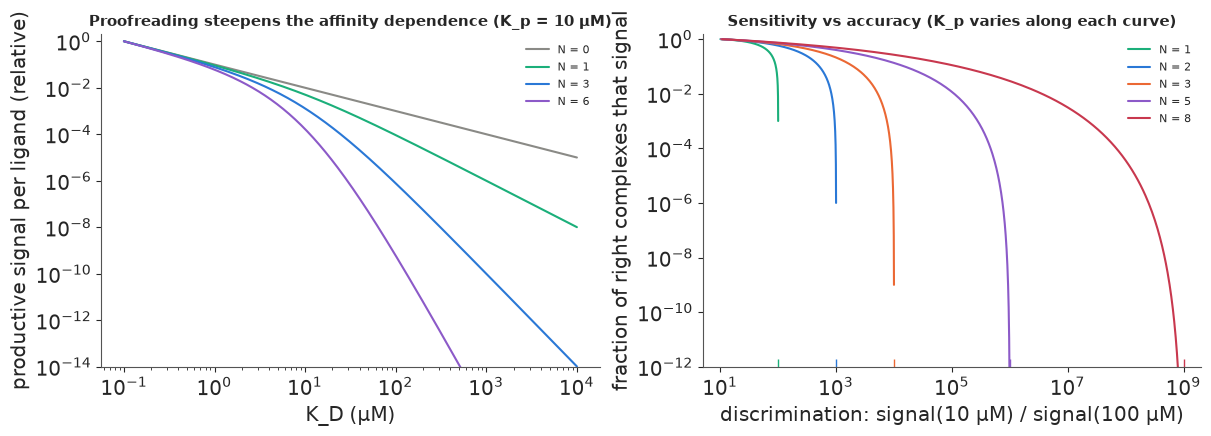

In [11]:
kd_axis = np.geomspace(0.1, 1e4, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for n_, c in zip([0, 1, 3, 6], [GREY, AQUA, BLUE, PURPLE]):
    sig_ = (1 / kd_axis) * (1 + kd_axis / 10.0) ** (-n_)
    axes[0].plot(kd_axis, sig_ / sig_[0], color=c, label=f"N = {n_}")
axes[0].set(xscale="log", yscale="log", ylim=(1e-14, 2), xlabel="K_D (µM)",
            ylabel="productive signal per ligand (relative)",
            title="Proofreading steepens the affinity dependence (K_p = 10 µM)")
axes[0].legend(fontsize=8)
kp_axis = np.geomspace(0.01, 1e4, 400)                         # K_p (uM)
KD_RIGHT, KD_WRONG = 10.0, 100.0
for n_, c in zip([1, 2, 3, 5, 8], [AQUA, BLUE, ORANGE, PURPLE, RED]):
    sens = (1 + KD_RIGHT / kp_axis) ** (-n_)
    disc = (KD_WRONG / KD_RIGHT) * ((1 + KD_WRONG / kp_axis) / (1 + KD_RIGHT / kp_axis)) ** n_
    axes[1].plot(disc, sens, color=c, label=f"N = {n_}")
    axes[1].plot(10.0 ** (n_ + 1), 1e-12, marker="|", ms=12, color=c)
axes[1].set(xscale="log", yscale="log", ylim=(1e-12, 1.5), xlim=(5, 2e9),
            xlabel="discrimination: signal(10 µM) / signal(100 µM)",
            ylabel="fraction of right complexes that signal",
            title="Sensitivity vs accuracy (K_p varies along each curve)")
axes[1].legend(fontsize=8);

**Left:** with $K_p = 10$ µM, occupancy alone ($N = 0$) makes the signal fall as $1/K_D$; every
proofreading step adds one more power of $K_D$ once $K_D \gg K_p$. **Right:** each curve follows one
$N$ as the proofreading rate varies. A fast step ($K_p$ large, top left) keeps the right ligand's
signal but discriminates only as well as occupancy (factor 10); a slow step (bottom right) approaches
the Hopfield limit $10^{N+1}$ (ticks on the bottom axis) while almost no right complexes signal
either. More steps buy a better trade-off curve, but moving along any of them trades sensitivity for
accuracy, and each step also adds $1/k_p$ to the time to decide.

## 7 · Data: how T cells respond to weaker and weaker antigens

Pettmann et al. (2021) measured the affinities of the 1G4 T-cell receptor for the cancer-testis
antigen NY-ESO-1 (peptide SLLMWITQV, "9V") and single-residue variants, down to very weak binders,
by surface plasmon resonance, and stimulated primary human T cells expressing 1G4 with target cells
pulsed with each peptide over a dose range. Activation is the percentage of T cells expressing the
early activation marker CD69. We use their source data for T cell blasts on U87 target cells (five
independent experiments) and their affinity table (37 °C; the paper's rule: the Bmax-constrained $K_D$
above 20 µM, the Bmax-fitted one otherwise).

pettmann2021_1g4_cd69: Activation of primary human T cell blasts expressing the 1G4 TCR by U87 target cells pulsed with one of 8 variants of the NY-ESO-1 peptide (SLLMWITQV = 9V and single substitutions), one row per well: experiment (date code, 5 independent experiments), peptide, dose_uM (peptide pulsing concentration, 0 = unpulsed), cd69_pct (% CD69-positive T cells). Per peptide: sequence, kd_um, kd_sd_um, kd_n (SPR KD mean, SD and number of measurements; the Bmax-constrained estimate where it exceeds 20 uM, else the Bmax-fitted one, the rule stated in the paper) and kd_method.
  source: Pettmann, Huhn, Abu Shah, Kutuzov, Wilson, Dustin, Davis, van der Merwe & Dushek (2021), The discriminatory power of the T cell receptor, eLife 10:e67092 (CC BY 4.0). ASSEMBLED from two of the article's source-data files: Figure 2 source data 1 (elife-67092-fig2-data1-v3.zip, folder 'Figure 2 - 1G4 blasts and U87', five CSVs) and Figure 1 source data 2 (elife-67092-fig1-data2-v3.csv, SPR affinities

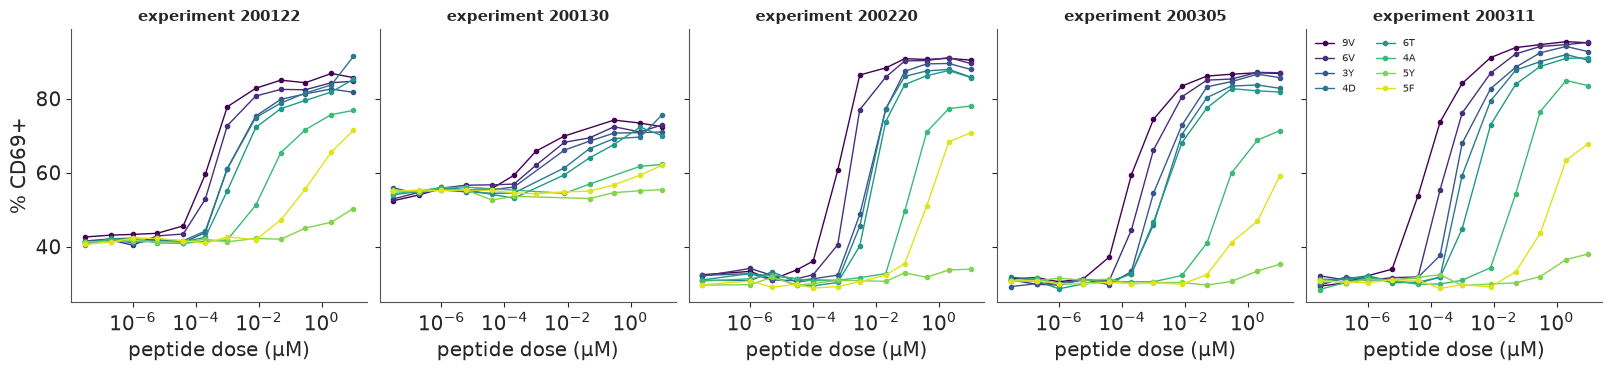

In [12]:
data.describe("pettmann2021_1g4_cd69")
tc = data.load("pettmann2021_1g4_cd69")
kd_tab = (tc.groupby("peptide")[["kd_um", "kd_sd_um", "kd_n", "sequence"]].first()
          .sort_values("kd_um"))
PEPS = kd_tab.index.tolist()
EXPS = sorted(tc["experiment"].astype(str).unique())
print(kd_tab)
print(f"{len(tc)} wells: {tc['experiment'].nunique()} experiments x {len(PEPS)} peptides x "
      f"~12 doses ({tc['dose_uM'][tc['dose_uM'] > 0].min():g}-{tc['dose_uM'].max():g} µM, plus unpulsed)")

cols = plt.cm.viridis(np.linspace(0, 0.95, len(PEPS)))
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
for ax, ex in zip(axes, EXPS):
    sub_ = tc[tc["experiment"].astype(str) == ex]
    for p_, c in zip(PEPS, cols):
        dd = sub_[sub_["peptide"] == p_].sort_values("dose_uM")
        ax.plot(dd["dose_uM"].clip(lower=3e-8), dd["cd69_pct"], "o-", ms=3, lw=1, color=c,
                label=p_.replace("NYE ", ""))
    ax.set(xscale="log", title=f"experiment {ex}", xlabel="peptide dose (µM)")
axes[0].set_ylabel("% CD69+")
axes[-1].legend(fontsize=7, ncol=2);

Each panel is one experiment; the leftmost points are the unpulsed controls. Weaker binders (lighter
colours) need more peptide to activate the same fraction of T cells, and the weakest (5F, $K_D \approx
1.3$ mM) still activates at high dose, the paper's headline finding. Two features matter for
modelling. The **baseline** (unstimulated CD69+) differs between experiments (about 30% to 55%), as
does the plateau, so both must be experiment-specific. And one peptide breaks the order: **5Y**
($K_D \approx 430$ µM) is far *less* potent than the weaker 5F in every experiment and barely leaves
baseline. Affinity is not the only thing that differs between peptides (how well each loads onto MHC,
for example, which these data do not measure), so a model should allow a peptide-specific deviation
from the affinity law.

## 8 · A proofreading model of potency, with the number of steps summed out

For peptide $j$ in experiment $e$ at dose $x$,

$$y = \beta_e + (\tau_e - \beta_e)\,\operatorname{logistic}\!\big(h\,(\log x - \log \text{EC}_{50,ej})\big) + \varepsilon,
  \qquad \varepsilon \sim \mathcal N(0, \sigma),$$

$$\log \text{EC}_{50,ej} = m_0 + (\log K_{D,j} - \log K_m) + N\left[\log\!\Big(1 + \frac{K_{D,j}}{K_p}\Big)
  - \log\!\Big(1 + \frac{K_m}{K_p}\Big)\right] + \delta_e + \eta_j .$$

The potency law is the proofreading signal of section 6; $K_m$ is a fixed reference affinity (the
geometric mean of the eight $K_D$s, about 120 µM), so $m_0$ is the log-EC50 of a ligand of that
affinity. $\delta_e$ is an experiment shift (zero-sum), $\eta_j \sim \text{StudentT}_3(0, \tau)$ a
peptide-specific deviation with heavy tails so that one odd peptide (5Y) cannot drag the rest. The
measured $K_D$s enter with their SPR uncertainty: $\log K_{D,j} \sim \mathcal N(\log \hat K_{D,j},
\text{CV}_j/\sqrt{n_j})$, floored at 0.1.

**The discrete $N$ and a multimodality trap.** $N \in \{1, \dots, 10\}$ is summed out: the model's
log-likelihood is $\log \sum_N p(N)\, p(y \mid N, \theta)$ (`pt.logsumexp` in a `pm.Potential`), and
$p(N \mid y)$ is recovered per draw. A first version (sampling $\log K_p$ directly, with
$N = 0, \dots, 8$ and a Gaussian $\eta$) failed: each $N$ wants a different $K_p$, so the posterior over $(K_p, \dots)$ is a mixture of separated modes, and
the four chains settled in different ones ($\hat r$ up to 1.44, 30 divergences, chains putting all
their mass on $N = 1$ or on $N = 0$ and $3$). The fix is to parameterise by what the data identify
whatever $N$ is: the **local discrimination power** at the reference affinity,
$\alpha_m = 1 + N K_m/(K_m + K_p)$, with prior $\alpha_m - 1 \sim \text{LogNormal}(0, 1)$. Given
$\alpha_m$, each $N$ implies its own $K_p$; values of $N < \alpha_m - 1$ are impossible and get zero
weight. Now the continuous parameters mean the same thing under every $N$, and $N$ only has to explain
the **curvature** of potency against affinity.

In [13]:
pep_i = pd.Index(PEPS).get_indexer(tc["peptide"])
exp_i = pd.Index(EXPS).get_indexer(tc["experiment"].astype(str))
assert (pep_i >= 0).all() and (exp_i >= 0).all()
dose = tc["dose_uM"].to_numpy()
y_obs = tc["cd69_pct"].to_numpy()
pulsed = dose > 0
log_dose = np.log(np.where(pulsed, dose, 1.0))
logkd_hat = np.log(kd_tab["kd_um"].to_numpy())
logkd_se = np.maximum(kd_tab["kd_sd_um"].to_numpy() / kd_tab["kd_um"].to_numpy()
                      / np.sqrt(kd_tab["kd_n"].to_numpy()), 0.1)
LOG_KM = float(logkd_hat.mean())
N_VALS = np.arange(1, 11)
print(f"reference affinity K_m = {np.exp(LOG_KM):.0f} µM")

coords = {"peptide": PEPS, "experiment": EXPS, "N": N_VALS}
with pm.Model(coords=coords) as kp_model:
    logkd = pm.Normal("logkd", logkd_hat, logkd_se, dims="peptide")
    alpha_m1 = pm.LogNormal("alpha_m1", 0.0, 1.0)
    alpha = pm.Deterministic("alpha", 1 + alpha_m1)
    m0 = pm.Normal("m0", -5.0, 4.0)
    sd_exp = pm.HalfNormal("sd_exp", 1.0)
    delta = pm.ZeroSumNormal("delta", sigma=sd_exp, dims="experiment")
    tau = pm.HalfNormal("tau", 0.5)
    eta = pm.StudentT("eta", nu=3, mu=0.0, sigma=tau, dims="peptide")
    h = pm.LogNormal("h", 0.0, 0.5)
    base = pm.Normal("base", 40.0, 15.0, dims="experiment")
    top = pm.Normal("top", 85.0, 15.0, dims="experiment")
    sigma = pm.HalfNormal("sigma", 5.0)

    nf = N_VALS.astype(float)[:, None]                       # (N, 1)
    share = (alpha - 1) / nf                                 # K_m / (K_m + K_p) for each N
    possible = share < 0.999
    share_c = pt.minimum(share, 0.999)
    log_kp = LOG_KM + pt.log1p(-share_c) - pt.log(share_c)   # (N, 1)
    pm.Deterministic("log_Kp", log_kp[:, 0], dims="N")
    proof = pt.log1p(pt.exp(logkd[None, :] - log_kp)) - pt.log1p(pt.exp(LOG_KM - log_kp))
    log_ec50 = m0 + (logkd[None, :] - LOG_KM) + nf * proof + eta[None, :]      # (N, peptide)
    pm.Deterministic("log_ec50_N", log_ec50, dims=("N", "peptide"))
    z = h * (log_dose[None, :] - log_ec50[:, pep_i] - delta[exp_i][None, :])
    frac = pt.where(pulsed[None, :], pm.math.sigmoid(z), 0.0)
    mu_y = base[exp_i][None, :] + (top - base)[exp_i][None, :] * frac
    ll_n = pt.sum(pm.logp(pm.Normal.dist(mu_y, sigma), y_obs[None, :]), axis=1)
    ll_n = pt.where(possible[:, 0], ll_n, -np.inf) + np.log(1 / len(N_VALS))
    pm.Potential("likelihood", pt.logsumexp(ll_n))
    pm.Deterministic("p_N", pt.exp(ll_n - pt.logsumexp(ll_n)), dims="N")

    t0 = time.time()
    idata_kp = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    t_kp = time.time() - t0
sum_kp = report(idata_kp, ["alpha", "m0", "tau", "eta", "h", "sigma", "sd_exp", "logkd", "base", "top"],
                "proofreading fit", t_kp)
print(az.summary(idata_kp, var_names=["alpha", "m0", "tau", "h", "sigma", "sd_exp"], round_to=3)
      [["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]])
print(az.summary(idata_kp, var_names=["eta"], round_to=2)[["mean", "sd", "eti89_lb", "eti89_ub"]])

reference affinity K_m = 116 µM


proofreading fit: 5 s, 1 divergences, max r_hat 1.012, min bulk ESS 364, warm-up 400 steps
         mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat
alpha   1.677  0.256     1.337     2.137   535.994  1.004
m0     -4.998  0.411    -5.627    -4.340   364.199  1.012
tau     0.820  0.248     0.463     1.256  2452.090  1.003
h       0.882  0.030     0.836     0.930  4827.681  1.001
sigma   2.944  0.096     2.796     3.105  5054.067  1.001
sd_exp  0.917  0.346     0.499     1.537  4553.803  1.001
             mean    sd  eti89_lb  eti89_ub
eta[NYE 9V]  0.12  0.49     -0.61      0.89
eta[NYE 6V]  0.06  0.49     -0.70      0.86
eta[NYE 3Y]  0.32  0.44     -0.33      1.01
eta[NYE 4D] -0.88  0.45     -1.63     -0.21
eta[NYE 6T] -0.67  0.45     -1.40      0.00
eta[NYE 4A]  1.37  0.57      0.40      2.25
eta[NYE 5Y]  6.97  0.82      5.59      8.18
eta[NYE 5F] -0.30  1.05     -2.01      1.23


The model fits in a few seconds with 1 divergence, $\hat r \le 1.012$ and bulk ESS above 350. The
**discrimination power** at the reference affinity is $\alpha_m \approx 1.7$ (89% interval 1.3-2.1):
clearly above the occupancy value 1, and close to the $\alpha \approx 2$ that Pettmann et al. report
from these kinds of data with a different potency measure (the dose giving 15% activation) and
regression. The dose-response curves have a shallow Hill slope ($h \approx 0.88$) and the residual
sd is about 3 percentage points.

The peptide deviations tell their own story. **5Y** is $e^{7} \approx 1{,}000$-fold less potent than
its affinity predicts ($\eta = 7.0$, 89% interval 5.6-8.2), 4A about $e^{1.4} \approx 4$-fold less, 4D
about 2.4-fold more. With 5Y handled by the heavy-tailed $\eta$, the typical peptide scatter is
$\tau \approx 0.8$ on the log scale: a peptide's potency is predicted from its affinity only to within
a factor of about two. That scatter, not the replicate noise, limits what the potency-affinity curve
can say about mechanism.

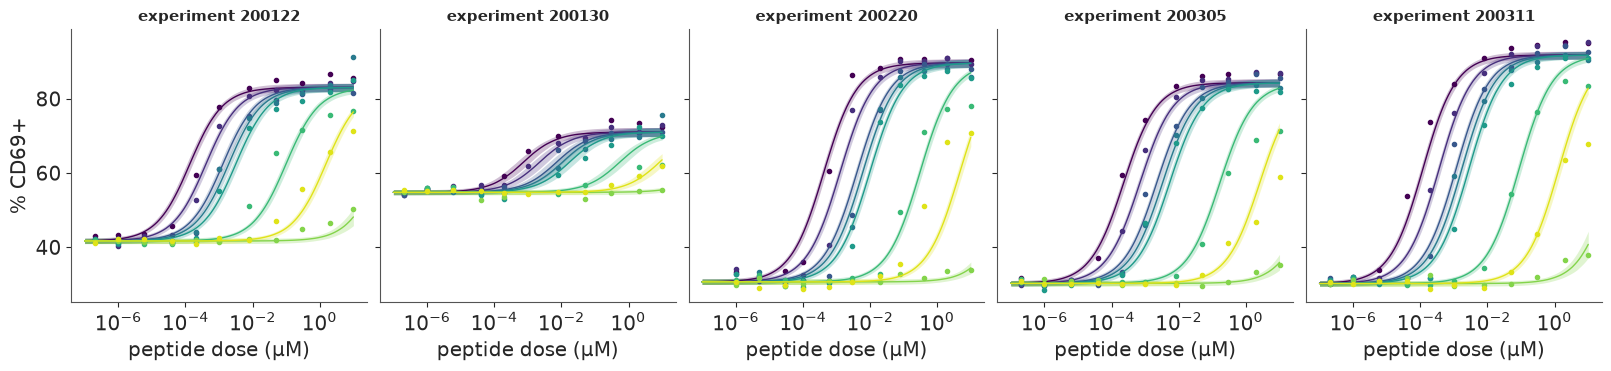

In [14]:
pb = az.extract(idata_kp, var_names=["p_N", "log_ec50_N", "h", "base", "top", "delta"],
                num_samples=1000, random_seed=RANDOM_SEED)
pN_draw = pb["p_N"].transpose("sample", "N").values                         # (S, N)
lec = pb["log_ec50_N"].transpose("sample", "N", "peptide").values           # (S, N, pep)
n_pick = np.array([np.random.default_rng(i).choice(len(N_VALS), p=p / p.sum()) for i, p in enumerate(pN_draw)])
lec_draw = lec[np.arange(len(n_pick)), n_pick]                              # (S, pep), N drawn per draw
hh, bb, tt = pb["h"].values, pb["base"].values, pb["top"].values
dl = pb["delta"].values
xg = np.geomspace(1e-7, 10, 120)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
r_ppc = np.random.default_rng(615)
for e_, (ax, ex) in enumerate(zip(axes, EXPS)):
    sub_ = tc[tc["experiment"].astype(str) == ex]
    for j, (p_, c) in enumerate(zip(PEPS, cols)):
        zz = hh[:, None] * (np.log(xg)[None, :] - lec_draw[:, j, None] - dl[e_][:, None])
        mu_ = bb[e_][:, None] + (tt[e_] - bb[e_])[:, None] / (1 + np.exp(-zz))
        lo, med, hi = np.quantile(mu_, [0.05, 0.5, 0.95], axis=0)
        ax.fill_between(xg, lo, hi, color=c, alpha=0.25, lw=0)
        ax.plot(xg, med, color=c, lw=1)
        dd = sub_[(sub_["peptide"] == p_) & (sub_["dose_uM"] > 0)]
        ax.plot(dd["dose_uM"], dd["cd69_pct"], "o", ms=3, color=c)
    ax.set(xscale="log", title=f"experiment {ex}", xlabel="peptide dose (µM)")
axes[0].set_ylabel("% CD69+");

Posterior predictive curves (median and 90% band of the mean response, with $N$ drawn from its
posterior in each draw) against the data. The model follows all five experiments, including the low
plateau of experiment 200130. It misses some detail at the weak end: in experiment 200220 the highest
doses of 4A and 5F sit below the curves, the pattern of weak ligands reaching a lower maximum that a
shared plateau cannot express (Pettmann et al. avoid it by measuring potency at 15% activation).
Potency is dominated by the midpoints, which the model gets right.

## 9 · Counting steps: the trade-off between $N$ and the proofreading rate

posterior P(N):  1:0.03  2:0.11  3:0.14  4:0.14  5:0.12  6:0.11  7:0.10  8:0.09  9:0.08  10:0.08
per chain, P(N <= 3): [0.4  0.23 0.25 0.23]
N =  1: K_p median     74.6 µM (90% 9.3-246)
N =  2: K_p median    243.6 µM (90% 84.9-588)
N =  3: K_p median    423.4 µM (90% 185.4-941)
N =  5: K_p median    783.1 µM (90% 386.4-1645)
N = 10: K_p median   1682.3 µM (90% 889.0-3406)


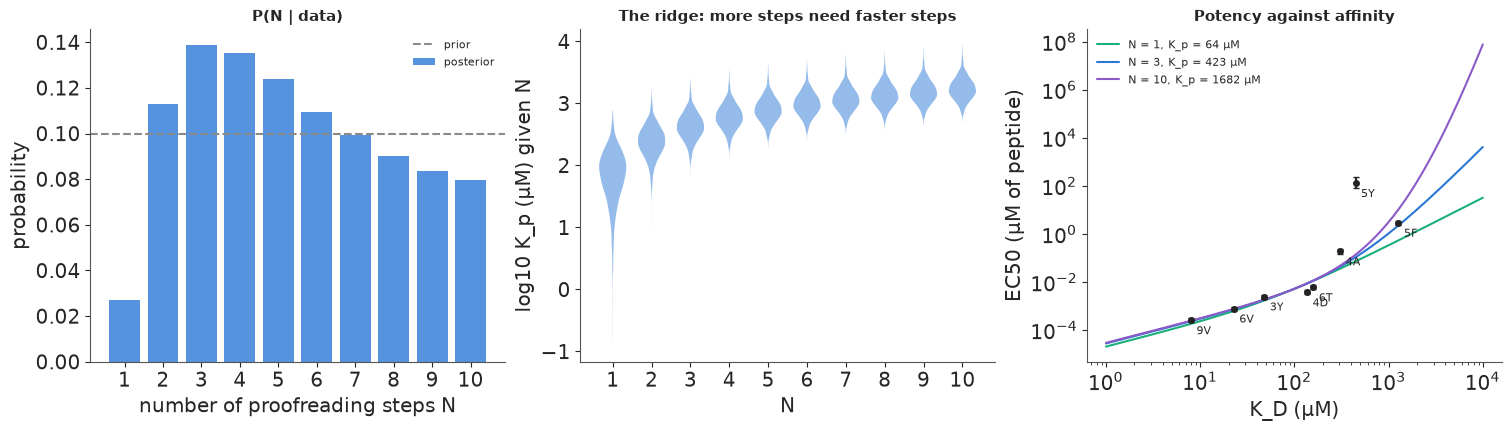

In [15]:
p_N = idata_kp.posterior["p_N"].mean(("chain", "draw")).values
p_N_chain = idata_kp.posterior["p_N"].mean("draw").values
print("posterior P(N):  " + "  ".join(f"{n}:{p:.2f}" for n, p in zip(N_VALS, p_N)))
print("per chain, P(N <= 3):", np.round(p_N_chain[:, :3].sum(axis=1), 2))
logkp_N = idata_kp.posterior["log_Kp"].values.reshape(-1, len(N_VALS))
alpha_d = idata_kp.posterior["alpha"].values.ravel()
for n_ in [1, 2, 3, 5, 10]:
    ok = alpha_d - 1 < n_ * 0.999
    q = np.exp(np.quantile(logkp_N[ok, n_ - 1], [0.05, 0.5, 0.95]))
    print(f"N = {n_:>2}: K_p median {q[1]:8.1f} µM (90% {q[0]:.1f}-{q[2]:.0f})")

logkd_d = az.extract(idata_kp, var_names=["logkd"], num_samples=1000, random_seed=RANDOM_SEED)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].bar(N_VALS, p_N, color=BLUE, alpha=0.8, label="posterior")
axes[0].axhline(1 / len(N_VALS), color=GREY, ls="--", label="prior")
axes[0].set(xlabel="number of proofreading steps N", ylabel="probability", xticks=N_VALS,
            title="P(N | data)")
axes[0].legend(fontsize=8)
for n_ in N_VALS:
    ok = alpha_d - 1 < n_ * 0.999
    if ok.mean() > 0.02:
        vp = axes[1].violinplot(logkp_N[ok, n_ - 1] / np.log(10), positions=[n_], widths=0.7,
                                showextrema=False)
        for b_ in vp["bodies"]:
            b_.set_facecolor(BLUE)
            b_.set_alpha(0.5)
axes[1].set(xlabel="N", ylabel="log10 K_p (µM) given N", xticks=N_VALS,
            title="The ridge: more steps need faster steps")
# potencies vs affinity, with the proofreading law for three N
ax = axes[2]
kd_line = np.geomspace(1, 1e4, 200)
a_med, m0_med = np.median(alpha_d), float(idata_kp.posterior["m0"].median())
for n_, c in zip([1, 3, 10], [AQUA, BLUE, PURPLE]):
    share_ = (a_med - 1) / n_
    kp_ = np.exp(LOG_KM) * (1 - share_) / share_
    line = m0_med + np.log(kd_line) - LOG_KM + n_ * (np.log1p(kd_line / kp_) - np.log1p(np.exp(LOG_KM) / kp_))
    ax.plot(kd_line, np.exp(line), color=c, label=f"N = {n_}, K_p = {kp_:.0f} µM")
lo, med, hi = np.exp(np.quantile(lec_draw, [0.05, 0.5, 0.95], axis=0))
kd_med = np.exp(np.median(logkd_d.values, axis=1))
ax.errorbar(kd_med, med, yerr=[med - lo, hi - med], fmt="o", color=INK, ms=4, capsize=2)
for j, p_ in enumerate(PEPS):
    ax.annotate(p_.replace("NYE ", ""), (kd_med[j], med[j]), textcoords="offset points", xytext=(4, -10),
                fontsize=8)
ax.set(xscale="log", yscale="log", xlabel="K_D (µM)", ylabel="EC50 (µM of peptide)",
       title="Potency against affinity")
ax.legend(fontsize=8);

**Left:** the posterior over the number of proofreading steps is almost flat from $N = 2$ to
$N = 10$; only $N = 1$ is disfavoured (0.03). The chain-level estimates of $P(N \le 3)$ range from
0.23 to 0.40, so the second decimal of $P(N)$ carries Monte Carlo error too. Pettmann et al. fitted
a proofreading model to their data and reported about 2.67 steps; these data are consistent with that
but cannot rule out many more. **Middle:** the ridge. Each $N$ explains the data with its own
proofreading threshold: $K_p \approx 240$ µM with two steps, 420 µM with three, 780 µM with five and
1,700 µM with ten. More steps must be individually faster (larger $K_p = k_p / k_{\text{on}}$) to give
the same overall discrimination. This is the same trade-off as between the number and the rates of
hidden steps in a motor's dwell time (E59, section 1): a sum of $N$ waits can be mimicked by fewer,
slower ones over the range the data cover. **Right:** why. The potency-affinity curves for $N = 1, 3,
10$ (at the median $\alpha_m$) coincide over the measured range (8-1,300 µM) and separate only for
weaker ligands, where the local slope heads towards $N + 1$. The per-peptide potencies (points, with
5Y far above) scatter around them by about the $\tau$ we estimated.

## 10 · Which ligands would count the steps?

The posterior says the current panel cannot tell $N$ apart. Which new peptide would help most?
Predict its log-EC50 under the posterior for each candidate affinity, and compute the **expected
information gain about $N$** from measuring it: the mutual information $I(N; y) = H(y) - H(y \mid N)$
between the discrete $N$ and the new measurement $y$. The new peptide gets its own deviation $\eta$,
so its measurement noise is $\tau$ (the peptide-to-peptide scatter), which dominates the replicate
error. Because $y$ is one-dimensional, both entropies are integrals on a grid over a Gaussian mixture
built from posterior draws (each draw weighted by its $p(N \mid \theta)$).

In [16]:
pd_ = az.extract(idata_kp, var_names=["alpha", "m0", "tau", "p_N"], num_samples=800, random_seed=RANDOM_SEED)
A_d, M_d, T_d = pd_["alpha"].values, pd_["m0"].values, pd_["tau"].values
P_d = pd_["p_N"].transpose("sample", "N").values
kd_cand = np.geomspace(0.01, 1e5, 36)
y_grid = np.linspace(-40, 40, 1601)
dy = y_grid[1] - y_grid[0]


def mean_log_ec50(kd, n_, alpha_, m0_):
    share_ = np.clip((alpha_ - 1) / n_, 1e-9, 0.999)
    lkp = LOG_KM + np.log1p(-share_) - np.log(share_)
    return m0_ + np.log(kd) - LOG_KM + n_ * (np.logaddexp(0, np.log(kd) - lkp) - np.logaddexp(0, LOG_KM - lkp))


def info_gain_N(kd):
    dens_n = np.zeros((len(N_VALS), len(y_grid)))
    for k_, n_ in enumerate(N_VALS):
        mu_ = mean_log_ec50(kd, n_, A_d, M_d)                           # (S,)
        w_ = P_d[:, k_]
        pdf = np.exp(-0.5 * ((y_grid[None, :] - mu_[:, None]) / T_d[:, None]) ** 2) / (T_d[:, None] * np.sqrt(2 * np.pi))
        dens_n[k_] = (w_[:, None] * pdf).sum(axis=0) / max(w_.sum(), 1e-300)
    pn_ = P_d.mean(axis=0)
    dens = (pn_[:, None] * dens_n).sum(axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        kl = np.where(dens_n > 1e-300, dens_n * np.log(dens_n / dens[None, :]), 0.0).sum(axis=1) * dy
    return float((pn_ * kl).sum())


t0 = time.time()
eig = np.array([info_gain_N(k_) for k_ in kd_cand])
# predicted EC50 of each candidate (posterior median over draws and N): is it inside the dose range?
ec50_cand = np.array([np.median(np.log(np.einsum("sn,sn->s", P_d, np.exp(np.stack(
    [mean_log_ec50(k_, n_, A_d, M_d) for n_ in N_VALS], axis=1))))) for k_ in kd_cand])
DOSE_MAX = tc["dose_uM"].max()
kd_limit = kd_cand[np.argmax(np.exp(ec50_cand) > DOSE_MAX)]
print(f"expected information gain for {len(kd_cand)} candidate affinities in {time.time() - t0:.1f} s")
print(f"entropy of the current P(N): {-(p_N * np.log(p_N)).sum():.2f} nats; "
      f"predicted EC50 exceeds the highest dose ({DOSE_MAX:g} µM) above K_D ~ {kd_limit:.0f} µM")
for k_, e_, ec_ in zip(kd_cand[::5], eig[::5], ec50_cand[::5]):
    print(f"  K_D = {k_:10.2f} µM: EIG = {e_:.3f} nats, predicted EC50 {np.exp(ec_):.2g} µM")

expected information gain for 36 candidate affinities in 1.8 s
entropy of the current P(N): 2.24 nats; predicted EC50 exceeds the highest dose (10 µM) above K_D ~ 2512 µM
  K_D =       0.01 µM: EIG = 0.006 nats, predicted EC50 2.7e-07 µM
  K_D =       0.10 µM: EIG = 0.006 nats, predicted EC50 2.7e-06 µM
  K_D =       1.00 µM: EIG = 0.006 nats, predicted EC50 2.7e-05 µM
  K_D =      10.00 µM: EIG = 0.004 nats, predicted EC50 0.00029 µM
  K_D =     100.00 µM: EIG = 0.004 nats, predicted EC50 0.0053 µM
  K_D =    1000.00 µM: EIG = 0.028 nats, predicted EC50 1.5 µM
  K_D =   10000.00 µM: EIG = 0.688 nats, predicted EC50 1.3e+05 µM
  K_D =  100000.00 µM: EIG = 1.275 nats, predicted EC50 1.2e+12 µM


One more peptide with $K_D$ below about 1 mM tells us essentially nothing about $N$ (less than 0.03
nats, against 2.24 nats of uncertainty): it would land where all the curves agree. The information
rises steeply for weaker ligands, but above about 2.5 mM the predicted EC50 is above the highest dose
used (10 µM, shaded), and at 10 mM it is predicted at around $10^5$ µM, which no peptide pulsing
could reach. So the experiment that counts the steps is one that measures responses to ligands weaker
than the weakest one here, which requires higher antigen densities than these assays used, or a more
sensitive read-out.

**Designed panels, simulated.** One peptide is not enough; what would a whole panel do? We simulate
potencies (log-EC50 with peptide scatter $\tau$ at its posterior median) for a true $N = 3$ with the
posterior-median $\alpha_m$, and compute $P(N \mid \text{panel})$ on a grid over $(\alpha_m, N)$ with
$m_0$ integrated out analytically (flat prior; the Gaussian integral leaves the centred residual sum of
squares). Four designs, 300 simulated panels each: the current eight affinities; sixteen peptides over
the same range; eight peptides reaching further into the weak range (up to 5 mM, which would need
higher peptide doses than used here); and the current eight with the peptide scatter cut to a third
(for example by measuring how much of each peptide is actually presented, and modelling it).

      current 8 peptides: P(N = 3) median 0.13 (> 0.5 in 0%); P(N in 2-4) median 0.39


  16 over the same range: P(N = 3) median 0.14 (> 0.5 in 0%); P(N in 2-4) median 0.40
     8 from 8 µM to 5 mM: P(N = 3) median 0.27 (> 0.5 in 1%); P(N in 2-4) median 0.71


  current 8, scatter / 3: P(N = 3) median 0.26 (> 0.5 in 0%); P(N in 2-4) median 0.65


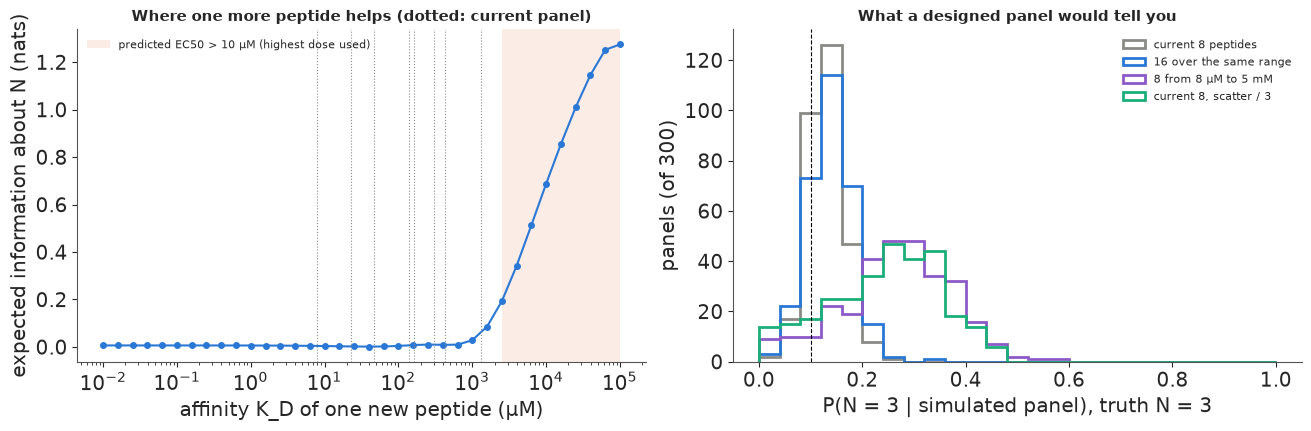

In [17]:
TAU_MED = float(np.median(T_d))
A_GRID = 1 + np.exp(np.linspace(np.log(0.02), np.log(20), 300))
LOG_PRIOR_A = -0.5 * np.log(A_GRID - 1) ** 2 - np.log(A_GRID - 1)        # LogNormal(0, 1) on alpha - 1
LOG_PRIOR_A += np.log(np.gradient(A_GRID))


def post_N(kds, y, tau_):
    """P(N | log-EC50s y at affinities kds), m0 integrated out, alpha on a grid."""
    logp = np.full((len(N_VALS), len(A_GRID)), -np.inf)
    for k_, n_ in enumerate(N_VALS):
        ok = A_GRID - 1 < 0.999 * n_
        mu_ = mean_log_ec50(kds[None, :], n_, A_GRID[ok, None], 0.0)          # (A, K)
        res = y[None, :] - mu_
        res -= res.mean(axis=1, keepdims=True)
        logp[k_, ok] = -0.5 * (res**2).sum(axis=1) / tau_**2 + LOG_PRIOR_A[ok]
    lp = np.logaddexp.reduce(logp, axis=1)
    return np.exp(lp - np.logaddexp.reduce(lp))


A_TRUE, N_TRUE = float(np.median(alpha_d)), 3
KD_NOW = np.exp(logkd_hat)
designs = {
    "current 8 peptides": (KD_NOW, TAU_MED),
    "16 over the same range": (np.geomspace(KD_NOW.min(), KD_NOW.max(), 16), TAU_MED),
    "8 from 8 µM to 5 mM": (np.geomspace(KD_NOW.min(), 5000, 8), TAU_MED),
    "current 8, scatter / 3": (KD_NOW, TAU_MED / 3),
}
r_des = np.random.default_rng(616)
des_res = {}
for name, (kds, tau_) in designs.items():
    mu_true = mean_log_ec50(kds, N_TRUE, A_TRUE, 0.0)
    des_res[name] = np.array([post_N(kds, mu_true + tau_ * r_des.standard_normal(len(kds)), tau_)
                              for _ in range(300)])
    pt3 = des_res[name][:, N_TRUE - 1]
    p23 = des_res[name][:, 1:4].sum(axis=1)
    print(f"{name:>24}: P(N = 3) median {np.median(pt3):.2f} (> 0.5 in {np.mean(pt3 > 0.5):.0%}); "
          f"P(N in 2-4) median {np.median(p23):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(kd_cand, eig, "o-", color=BLUE, ms=4)
for k_ in KD_NOW:
    axes[0].axvline(k_, color=GREY, lw=0.8, ls=":")
axes[0].axvspan(kd_limit, kd_cand.max(), color=ORANGE, alpha=0.12, lw=0,
                label=f"predicted EC50 > {DOSE_MAX:g} µM (highest dose used)")
axes[0].set(xscale="log", xlabel="affinity K_D of one new peptide (µM)",
            ylabel="expected information about N (nats)",
            title="Where one more peptide helps (dotted: current panel)")
axes[0].legend(fontsize=8, loc="upper left")
for (name, v), c in zip(des_res.items(), [GREY, BLUE, PURPLE, AQUA]):
    axes[1].hist(v[:, N_TRUE - 1], bins=np.linspace(0, 1, 26), histtype="step", lw=2, color=c, label=name)
axes[1].axvline(1 / len(N_VALS), color="k", ls="--", lw=0.8)
axes[1].set(xlabel="P(N = 3 | simulated panel), truth N = 3", ylabel="panels (of 300)",
            title="What a designed panel would tell you")
axes[1].legend(fontsize=8);

Sixteen peptides over the same affinity range are no better than eight: $P(N = 3)$ stays near its
prior (median 0.14), because the extra peptides land where all $N$ agree. Extending eight peptides to
5 mM doubles the median posterior probability of the true $N$ (0.27) and puts 0.71 of the mass on
$N = 2$-4; removing two thirds of the peptide scatter does almost as well (0.26 and 0.65). Neither makes
$N = 3$ a confident answer: rarely does any simulated panel give it more than 0.5. Counting proofreading
steps from potencies alone is hard, and the better investment is in the two levers the design exposes:
**weaker ligands** and **less unexplained peptide-to-peptide variation**. Time-resolved signalling
(the delay $N/k_p$ of section 6) would add a rate and attack the ridge from another side, as the early
images did in Part A.

## Summary

- **Turing's instability** needs a self-enhancing activator, a stabilising inhibitor, and an inhibitor
  that diffuses at least $d_c$ times faster; linear stability gives $d_c$ in closed form, the band of
  unstable wavenumbers and the fastest mode $k_m$. A semi-implicit FFT solver makes spots at $d = 20$
  and stripes just above onset (sections 1-2).
- **A settled pattern identifies a length scale.** Its wavelength (after calibrating linear theory
  against simulation: settled patterns ran about 7% shorter than $2\pi/k_m$ on average) leaves the kinetic
  parameters spread along ridges; importance sampling from the prior gives that posterior without a
  simulator in the loop (section 3).
- **The onset identifies the rates.** While the pattern is small, every Fourier mode is an exact
  linear Gaussian process; grouping modes by $k^2$ and a Woodbury identity reduce the likelihood to
  2 × 2 algebra, and four early images recovered $d$, $\gamma$, $a$ and $b$. Low-rank mass-matrix
  adaptation diverged on this curved posterior; the diagonal default with `target_accept=0.95` did
  not (section 4).
- **Whether the Turing conditions hold** is a posterior probability that depends on kinetics as much
  as on diffusivities: about 0.6-0.8 for Lefty against Cyclops, 0.04-0.17 against Squint, under a
  stated kinetics prior. Turing space is small at modest diffusivity ratios (5% of the Schnakenberg
  prior at $d = 10$): the robustness problem (section 5).
- **Kinetic proofreading** buys discrimination up to (ratio)$^{N+1}$ with $N$ steps and pays in
  sensitivity and delay; its signature is a potency-affinity slope $\alpha$ rising from 1 to $N + 1$
  (section 6).
- On real T-cell data (Pettmann et al. 2021), a proofreading potency model with $N$ **summed out**
  gives $\alpha_m \approx 1.7$, a peptide-level scatter of a factor of about two and one strong outlier
  (5Y). Sampling $K_p$ directly split the chains between $N$-specific modes; parameterising by the
  identified $\alpha_m$ fixed it. $P(N)$ stays nearly flat for $N \ge 2$: $N$ and the step rate trade
  off along a ridge, like hidden steps in E59 (sections 7-9).
- **Design:** information about $N$ lives in ligands weaker than about 1 mM, at or beyond the doses
  used; more peptides in the same range do not help, while weaker ligands or less peptide scatter do
  (section 10).

## Try it yourself

1. **Gierer-Meinhardt and a real spacing.** Replace the Schnakenberg kinetics by Gierer-Meinhardt
   ($\partial_t u = u^2/v - u + \nabla^2 u + \text{basal}$, $\partial_t v = \gamma(u^2 - v) + d\nabla^2
   v$). Derive its Jacobian, redo the calibration of section 3, and compare the ridge of parameters a
   given wavelength allows. Which parameter combination does the wavelength identify in each model?
2. **Fewer, noisier early images.** Refit section 4 with only two early images, with camera noise
   ten times larger, or with the fourth image taken at $t = 30$ (where the nonlinearity has started).
   When does the linear likelihood become overconfident, and how would you detect it from the data
   alone (hint: compare the per-mode residual variance $x^H C^{-1} x$ across wavenumbers)?
3. **P15, other cells, and continuous $N$.** Pettmann et al. used the dose giving 15% activation
   (P15) rather than EC50, and they also measured naive and memory T cells on dendritic cells (the
   other folders of their Figure 2 source data). Fit the same model to those data, and replace the
   discrete $N$ by a continuous one (the factor $(1 + K_D/K_p)^{-N}$ is defined for any $N > 0$). Does
   the posterior for $\alpha_m$ differ between cell types, and is $N$ any better identified?